# 05 · Versión 2 del modelo: RR normalizado por paciente

**Qué motiva esta versión.** En DS2, el modelo v1 detectó apenas el 15.5 % de los latidos S, y la
causa está identificada: el registro 232 aporta el 75 % de los S del conjunto, es bradicárdico, y
v1 usa intervalos RR **absolutos**. Sus latidos prematuros tienen RR de 0.73 s, un valor
perfectamente normal para los pacientes de entrenamiento.

**Regla del juego: DS2 ya se gastó.** Se evaluó una vez y no se vuelve a abrir. Entonces:

- Todo lo de este notebook se decide **solo con validación cruzada por paciente dentro de DS1**,
  con los mismos 5 folds.
- **No se puede afirmar que la v2 sea mejor en DS2**, y los números publicados de DS2 siguen
  siendo los de v1. Medir la v2 ahí sería elegir modelo mirando el conjunto de prueba.
- Para demostrar la mejora hace falta **validación externa** (por ejemplo INCART), que queda como
  trabajo siguiente.

**Decidido antes de correr nada:**

- **Candidatos** (los tres con morfología y latido submuestreado):
  A) v1: RR absolutos + cocientes · B) solo cocientes · C) RR dividido por la **mediana del RR del
  propio registro**, más los cocientes.
- **Criterio:** mayor F1 macro out-of-fold. **Si quedan dentro de 0.01** (ruido, según la
  variabilidad entre folds de la Fase 3), **desempata la Se de S**, que es la debilidad que
  motivó esta versión.
- **Prueba de estrés:** simular pacientes más lentos multiplicando sus RR y medir la caída.

> Proyecto educativo y de investigación. No es un dispositivo médico.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ecg import config
from ecg.evaluate import per_class_metrics, summary
from ecg.features import build_features
from ecg.models.baseline import BaselineClassifier
from ecg.segment import load_split
from ecg.train import BASELINE_CHOICE, patient_folds

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.precision", 3)

ds1 = load_split("ds1")
X, F, y, groups = ds1["X"], ds1["F"], ds1["y"], ds1["record"]
CANDIDATOS = {"A · v1 (RR absoluto)": "rr+morph+wave",
              "B · solo cocientes": "rr_ratios+morph+wave",
              "C · RR normalizado": "rr_norm+morph+wave"}
ESCALAS = [1.0, 1.25, 1.5, 2.0]

def entrenar_folds(feature_set, F_train=F):
    """Modelos por fold + predicciones out-of-fold, con el protocolo de la Fase 3."""
    Z, _ = build_features(X, F_train, feature_set, records=groups)
    modelos, oof = [], np.empty(len(y), dtype="<U1")
    for tr, va in patient_folds(groups):
        m = BaselineClassifier(kind=BASELINE_CHOICE["kind"], params=BASELINE_CHOICE["params"],
                               feature_set=feature_set,
                               weight_power=BASELINE_CHOICE["weight_power"]).fit(Z[tr], y[tr])
        oof[va] = m.predict(Z[va])
        modelos.append((m, va))
    return modelos, oof

## 1. Comparación de candidatos (validación cruzada por paciente, DS1)

In [2]:
modelos, oof, filas = {}, {}, []
for nombre, fs in CANDIDATOS.items():
    t0 = time.time()
    modelos[nombre], oof[nombre] = entrenar_folds(fs)
    filas.append({"candidato": nombre, "features": fs, **summary(y, oof[nombre]),
                  "segundos": round(time.time() - t0)})
tabla = pd.DataFrame(filas).set_index("candidato")
COLS = ["macro_f1", "N_F1", "S_Se", "S_+P", "S_F1", "V_Se", "V_+P", "V_F1", "F_F1"]
tabla[COLS + ["segundos"]].round(3)

,macro_f1,N_F1,S_Se,S_+P,S_F1,V_Se,V_+P,V_F1,F_F1,segundos
candidato,,,,,,,,,,
A · v1 (RR absoluto),0.493,0.947,0.319,0.445,0.372,0.914,0.509,0.654,0.000,13
B · solo cocientes,0.484,0.940,0.320,0.385,0.350,0.909,0.490,0.637,0.009,13
C · RR normalizado,0.487,0.939,0.370,0.367,0.368,0.910,0.480,0.628,0.014,13


In [3]:
mejor_f1 = tabla["macro_f1"].max()
empate = tabla[tabla["macro_f1"] >= mejor_f1 - 0.01]
elegido = empate["S_Se"].idxmax() if len(empate) > 1 else tabla["macro_f1"].idxmax()
print(f"Dentro de 0.01 del mejor F1 macro: {list(empate.index)}")
print(f"Desempate por Se de S -> elegido: {elegido} ({CANDIDATOS[elegido]})")

Dentro de 0.01 del mejor F1 macro: ['A · v1 (RR absoluto)', 'B · solo cocientes', 'C · RR normalizado']
Desempate por Se de S -> elegido: C · RR normalizado (rr_norm+morph+wave)


**Conclusiones:**

- Los tres candidatos quedan en **0.484–0.493**, es decir, **dentro del ruido**: la misma
  diferencia que en la Fase 3 resultó no significativa con 22 pacientes.
- Se aplica el desempate declarado de antemano: **gana C, el RR normalizado por la mediana del
  registro**, con **Se de S 0.370** contra 0.319 de v1 (+16 % relativo).
- El precio: la +P de V baja de 0.509 a 0.480 y la F1 de N de 0.947 a 0.939. Es un intercambio
  consciente a favor de detectar latidos supraventriculares.

## 2. Prueba de estrés: ¿qué pasa con un paciente más lento?

In [4]:
estres = []
for nombre, fs in CANDIDATOS.items():
    for k in ESCALAS:
        F_lento = F.copy()
        F_lento[:, :2] *= k           # mismo patrón, corazón k veces más lento
        Z_lento, _ = build_features(X, F_lento, fs, records=groups)
        pred = np.empty(len(y), dtype="<U1")
        for m, va in modelos[nombre]:  # modelos entrenados con el ritmo original
            pred[va] = m.predict(Z_lento[va])
        estres.append({"candidato": nombre, "escala_RR": k, **summary(y, pred)})
estres = pd.DataFrame(estres)
estres.pivot(index="candidato", columns="escala_RR", values=["macro_f1", "S_Se"]).round(3)

macro_f1                        S_Se                     
escala_RR                1.00   1.25   1.50   2.00   1.00   1.25   1.50   2.00
candidato                                                                     
A · v1 (RR absoluto)    0.493  0.503  0.488  0.458  0.319  0.308  0.247  0.133
B · solo cocientes      0.484  0.484  0.484  0.484  0.320  0.320  0.320  0.320
C · RR normalizado      0.487  0.487  0.487  0.487  0.370  0.370  0.370  0.370

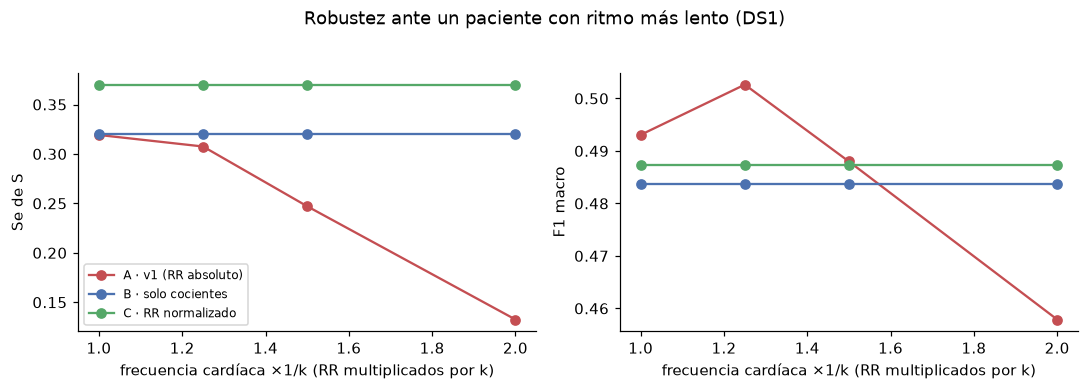

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
colores = {"A · v1 (RR absoluto)": "#C44E52", "B · solo cocientes": "#4C72B0",
           "C · RR normalizado": "#55A868"}
for ax, metrica, etiqueta in [(axes[0], "S_Se", "Se de S"), (axes[1], "macro_f1", "F1 macro")]:
    for nombre, g in estres.groupby("candidato"):
        ax.plot(g.escala_RR, g[metrica], marker="o", color=colores[nombre], label=nombre)
    ax.set_xlabel("frecuencia cardíaca ×1/k (RR multiplicados por k)")
    ax.set_ylabel(etiqueta)
axes[0].legend(fontsize=8)
fig.suptitle("Robustez ante un paciente con ritmo más lento (DS1)", y=1.03)
fig.tight_layout(); fig.savefig(config.REPORTS_DIR / "figures" / "v2_stress_test.png",
                                bbox_inches="tight")

**Conclusiones:**

- **v1 se degrada con el ritmo:** con los RR al doble (un paciente a la mitad de frecuencia), su
  Se de S cae de 0.319 a **0.133**, un 58 % menos. Es exactamente el mecanismo que explica el
  0.4 % del registro 232 en DS2.
- **B y C son invariantes por construcción:** sus features no cambian al escalar todos los
  intervalos, así que la métrica se mantiene idéntica.
- Ojo con la interpretación: esta prueba **no demuestra** que v2 detecte mejor a un bradicárdico
  real, porque un paciente así también tiene diferencias de morfología. Lo que demuestra es que
  **v1 tiene una dependencia del ritmo absoluto que v2 no tiene**.

## 3. Dónde cambia el comportamiento dentro de DS1

In [6]:
mediana_rr = pd.Series({int(r): float(np.median(F[groups == r, 0])) for r in np.unique(groups)})
comp = pd.DataFrame({
    "mediana RR (s)": mediana_rr,
    "latidos S": pd.Series({int(r): int(((groups == r) & (y == "S")).sum()) for r in mediana_rr.index}),
})
for nombre in ["A · v1 (RR absoluto)", "C · RR normalizado"]:
    comp[f"S_Se {nombre[0]}"] = pd.Series({
        int(r): per_class_metrics(y[groups == r], oof[nombre][groups == r]).loc["S", "Se"]
        for r in mediana_rr.index})
comp = comp[comp["latidos S"] >= 20].sort_values("mediana RR (s)", ascending=False)
comp.round(3)

,mediana RR (s),latidos S,S_Se A,S_Se C
124,1.122,31,0.000,0.000
207,0.931,106,0.000,0.000
220,0.892,94,0.819,0.947
201,0.861,128,0.250,0.289
118,0.806,96,0.000,0.000
223,0.697,73,0.479,0.425
209,0.625,383,0.381,0.473


**Conclusión:** dentro de DS1 el efecto es pequeño, porque **no hay ningún paciente tan lento como
el 232** (la mediana de RR más alta de DS1 está lejos de los 1.87 s de ese registro). Esa es
justamente la razón por la que la validación cruzada no podía detectar este problema, y por la que
la diferencia entre candidatos quedó dentro del ruido. El argumento a favor de v2 es **mecánico**
(la feature no depende de la frecuencia basal), no estadístico.

## 4. Modelo v2

In [7]:
import json
meta = json.loads((config.REPORTS_DIR / "baseline_v2_cv.json").read_text())
v1 = json.loads((config.REPORTS_DIR / "baseline_xgb_cv.json").read_text())["cv"]
print("Entrenado con:", meta["feature_set"], "|", len(meta["feature_names"]), "features")
pd.DataFrame({"v1 (CV DS1)": {k: v1[k] for k in COLS},
              "v2 (CV DS1)": {k: meta["cv"][k] for k in COLS}}).round(3)

Entrenado con: rr_norm+morph+wave | 41 features


,v1 (CV DS1),v2 (CV DS1)
macro_f1,0.493,0.487
N_F1,0.947,0.939
S_Se,0.319,0.370
S_+P,0.445,0.367
S_F1,0.372,0.368
V_Se,0.914,0.910
V_+P,0.509,0.480
V_F1,0.654,0.628
F_F1,0.000,0.014


## Resumen

**v2 = XGBoost con RR normalizado por la mediana del registro** (`python -m ecg.train baseline-v2`,
guardado en `models/baseline_v2.joblib`). Se eligió con la regla declarada antes de correr los
experimentos: los tres candidatos empataron en F1 macro dentro del ruido y desempató la Se de S
(0.370 contra 0.319).

**Qué se puede afirmar y qué no**

| Afirmación | ¿Se puede sostener? |
|---|---|
| v2 depende menos de la frecuencia cardíaca basal | **Sí**: es invariante por construcción y la prueba de estrés lo confirma |
| v2 detecta más S en validación por paciente (DS1) | **Sí**: 0.370 vs 0.319 |
| v2 habría funcionado mejor en el registro 232 de DS2 | **No verificado**: medirlo ahora sería elegir modelo mirando el conjunto de prueba |
| v2 es mejor en general | **No**: pierde algo de +P en V y de F1 en N |

**El resultado publicado en DS2 sigue siendo el de v1** (F1 macro 0.512). La v2 se reporta como
mejora validada en DS1, pendiente de validación externa (INCART) — que es lo que corresponde
cuando el conjunto de prueba ya se usó.